Saving Sample - Superstore.csv to Sample - Superstore (19).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   ob

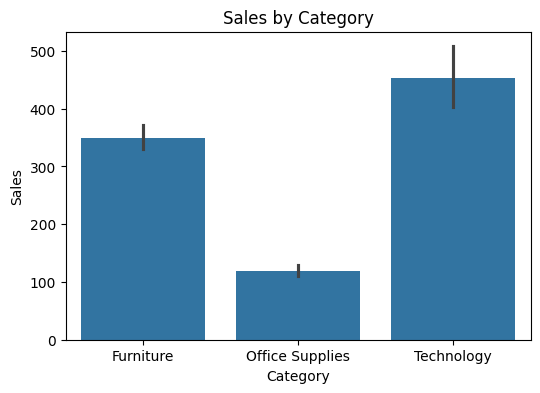

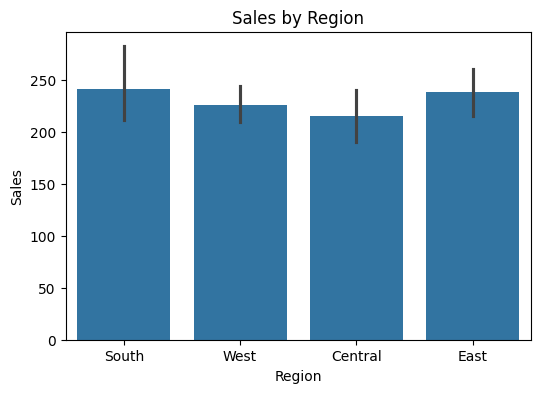

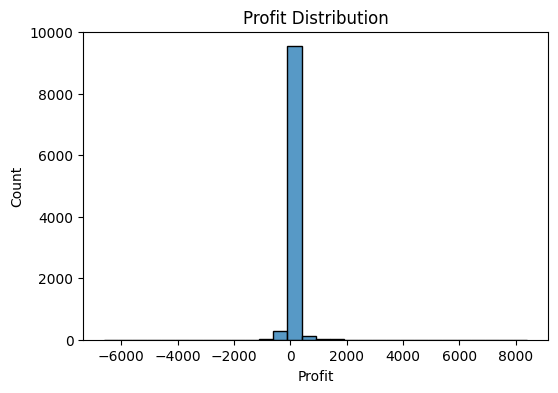

Mean Squared Error: 2994220.1527997856
R2 Score: -4.068942604517702


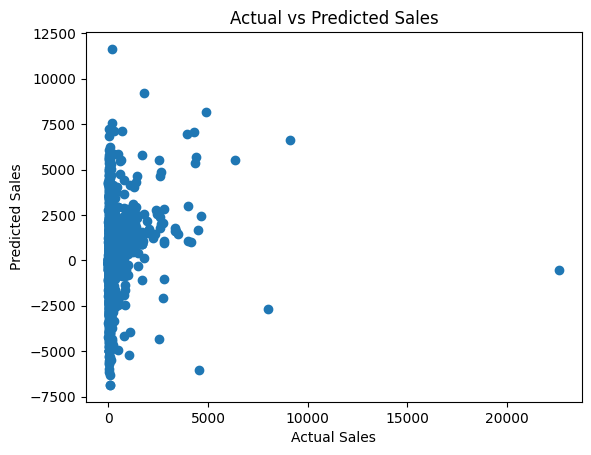

In [ ]:
#PART 1
#INDEPENDENT PROJECT


#uploading the file
from google.colab import files
uploaded = files.upload()


#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#loading dataset
df = pd.read_csv('Sample - Superstore (3).csv', encoding='latin1')
df.head()


#EDA
df.shape
df.columns
df.info()
df.describe()


#checking missing values
df.isnull().sum()


#data visualization (EDA)

#Sales by Category
plt.figure(figsize=(6,4))
sns.barplot(x='Category', y='Sales', data=df)
plt.title("Sales by Category")
plt.show()

#Sales by Region
plt.figure(figsize=(6,4))
sns.barplot(x='Region', y='Sales', data=df)
plt.title("Sales by Region")
plt.show()

#Profit Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Profit'], bins=30)
plt.title("Profit Distribution")
plt.show()


#preprocessing

#Convert categorical columns:
df = pd.get_dummies(df, drop_first=True)
df.head()



#model Training

#we will predict sales
from sklearn.model_selection import train_test_split
X = df.drop('Sales', axis=1)
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



#train machine learning model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)



#prediction
y_pred = model.predict(X_test)
y_pred


#Model Evaluation
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)



Plot Prediction vs Actual
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

Saving student_performance_updated_1000 1.csv to student_performance_updated_1000 1 (7).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


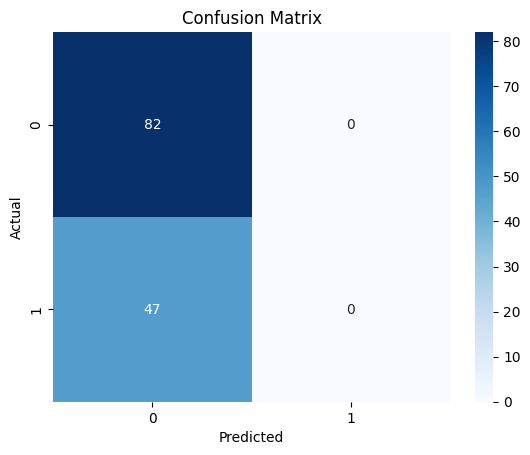

R2 Score: -0.022404613536723295
MAE: 8.316608829852541
MSE: 93.48173280936638


In [9]:

#PART 2 - (A) STUDENT PERFORMANCE DATASET
#A) Multinomial Classification
# Create performance categories (Low / Medium / High)
# Apply Multinomial Logistic Regression
# Evaluate using Accuracy & Confusion Matrix



import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Load Dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("student_performance_updated_1000 1.csv")
df.head()


#Dataset Information
df.info()
df.describe()


#Check Missing Values
df.isnull().sum()

#Remove Missing Values
df = df.dropna()

df.isnull().sum()

#Create Performance Category (Low / Medium / High)
def performance_category(score):
    if score < 60:
        return "Low"
    elif score < 80:
        return "Medium"
    else:
        return "High"

df["Performance"] = df["FinalGrade"].apply(performance_category)

df.head()



#Select Features
features = df[['StudyHoursPerWeek','AttendanceRate','PreviousGrade']]
target = df['Performance']


#train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)



#Multinomial Logistic Regression

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(multi_class='multinomial', max_iter=1000)
model.fit(X_train, y_train)



#prediction
y_pred = model.predict(X_test)
y_pred[:10]


#accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


#Confusion Matrix - to evaluate how well the classification model is performing. It helps us see where the model predicts correctly and where it makes mistakes.
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()





#PART (B) REGRESSION

 #Predict final score using Linear Regression
 #Evaluate using R², MAE, MSE



#Select Features
X = df[['StudyHoursPerWeek','AttendanceRate','PreviousGrade']]
y = df['FinalGrade']


#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#Linear Regression
from sklearn.linear_model import LinearRegression
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)


#prediciton
y_pred = reg_model.predict(X_test)
y_pred[:10]




#model evalution
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))